In [1]:
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.modeling import models, fitting

from dust_extinction.averages import CT06_MWGC 

from smart_plotters.jwst_plots import JWSTCatalog, make_cat_use, make_brick_cat
from smart_plotters.cutout_plot import get_cutout_405, get_cutout_jwst_ice
import smart_plotters.co_ice as co_map
from smart_plotters import cmd_plot 

from mpl_plot_templates import adaptive_param_plot


        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
/blue/adamginsburg/adamginsburg/jwst/brick-jwst-2221/brick2221/analysis/plot_tools.py:625: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).to(u.marcsec).value:0.1f}', fontsize=10)
/blue/adamginsburg/adamginsburg/jwst/brick-jwst-2221/brick2221/analysis/plot_tools.py:625: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).to(u.marcsec).value:0.1f}', fontsize=10)
/blue/adamginsburg/adamginsburg/jwst/brick-jwst-2221/brick2221/analysis/plot_tools.py:631: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).

In [2]:
cat_use = make_cat_use()


In [3]:
# sel = ((basetable['nmatch_good_f410m'] >= 5) |
#        (basetable['nmatch_good_f466n'] >= 5) |
#        (basetable['nmatch_good_f444w'] >= 5) |
#        (basetable['nmatch_good_f356w'] >= 5)
#       ) & (basetable['qfit_f405n'] < 0.40) & (basetable['qfit_f410m'] < 0.40)
# plot_tools.xmatch_plot(basetable, sel=sel, axlims=[-0.15, 0.15, -0.15, 0.15])

In [26]:
def astrometry_sel(cat):
    basetable = cat.catalog
    sel = ((basetable['nmatch_good_f410m'] >= 2) |
           (basetable['nmatch_good_f466n'] >= 2) |
           #(basetable['nmatch_good_f444w'] >= 5) |
           #(basetable['nmatch_good_f356w'] >= 5)
           (basetable['nmatch_good_f405n'] >= 2) |
           (basetable['nmatch_good_f182m'] >= 2) | 
            (basetable['nmatch_good_f187n'] >= 2) |
            (basetable['nmatch_good_f212n'] >= 2)
          ) & ((basetable['qfit_f405n'] < 0.06) & (basetable['qfit_f410m'] < 0.06) 
            & (basetable['qfit_f182m'] < 0.06) & (basetable['qfit_f187n'] < 0.06) 
            & (basetable['qfit_f212n'] < 0.06) & (basetable['qfit_f466n'] < 0.06))
    return sel

In [27]:
sel_cloudc = astrometry_sel(cat_use)


In [28]:
fn = '/orange/adamginsburg/jwst/cloudc/images/jw02221-o002_t001_nircam_clear-f405n-merged_i2d.fits'
hdu = fits.open(fn)
ww = WCS(hdu['SCI'].header)
nanfield = np.nan * hdu['SCI'].data

In [29]:
from grid_strategy import strategies
sqgrid = strategies.SquareStrategy()

3.6925781437547918 mas
5.145812720712038 mas
8.87076517482103 mas
6.731905729910074 mas
11.422116674181739 mas


/scratch/local/29356267/ipykernel_1976316/2186996984.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


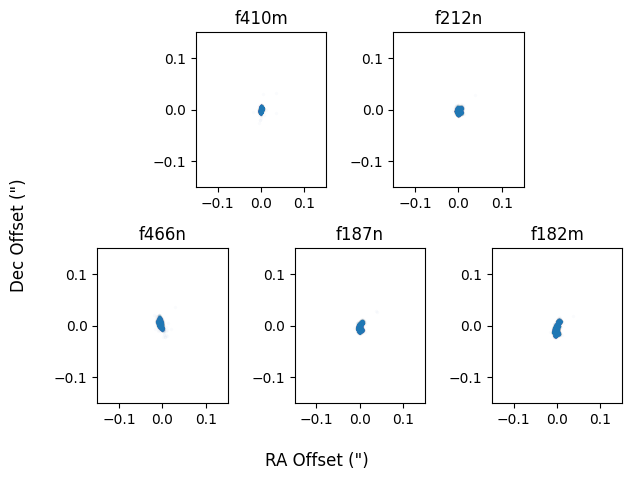

<Figure size 640x480 with 0 Axes>

In [30]:
#fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig1 = plt.figure(1)#, figsize=(15, 10))

basetable = cat_use.catalog
basecrds = basetable[f'skycoord_f405n']
radiffs = []
decdiffs = []

gridspec = sqgrid.get_grid(len(cat_use.filters)-1)
ii = 0
for i in range(6):
    filtername = cat_use.filters[i]
    if filtername == 'f405n':
        continue
    ax = fig1.add_subplot(gridspec[ii])#axes.flatten()[i]
    ii += 1

    thissel = ~basetable[f'flux_{filtername}'].mask & sel_cloudc
    crds = basetable[f'skycoord_{filtername}'][thissel]
    radiff = (crds.ra-basecrds.ra[thissel]).to(u.arcsec)
    decdiff = (crds.dec-basecrds.dec[thissel]).to(u.arcsec)
    rms_ra = np.sqrt(np.sum(radiff**2)/len(radiff))
    rms_dec = np.sqrt(np.sum(decdiff**2)/len(decdiff))
    rms = np.sqrt(rms_ra**2 + rms_dec**2)
    print(rms.to(u.mas))
    #print(rms_ra.to(u.mas), rms_dec.to(u.mas))

    sep = basetable[f'sep_{filtername}'][thissel].quantity.to(u.arcsec)

    ax.scatter(radiff, decdiff, marker=',', s=1, alpha=0.01)
    ax.set_title(filtername)
    ax.set_xlim(-0.15, 0.15)
    ax.set_ylim(-0.15, 0.15)

fig1.supxlabel("RA Offset (\")")
fig1.supylabel("Dec Offset (\")")
fig1.tight_layout()

plt.tight_layout()

3.6925781437547918 mas
5.145812720712038 mas
8.87076517482103 mas
6.731905729910074 mas
11.422116674181739 mas


/scratch/local/29356267/ipykernel_1976316/1459093157.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


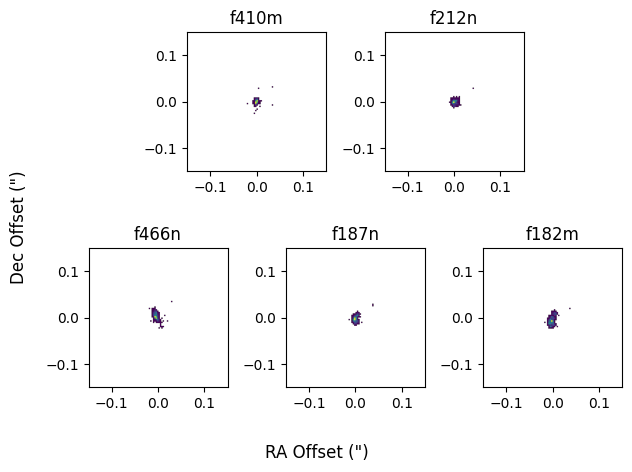

<Figure size 640x480 with 0 Axes>

In [31]:
#fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig1 = plt.figure(1)#, figsize=(15, 10))

basetable = cat_use.catalog
basecrds = basetable[f'skycoord_f405n']
radiffs = []
decdiffs = []

gridspec = sqgrid.get_grid(len(cat_use.filters)-1)
ii = 0
for i in range(6):
    filtername = cat_use.filters[i]
    if filtername == 'f405n':
        continue
    ax = fig1.add_subplot(gridspec[ii])#axes.flatten()[i]
    ii += 1

    thissel = ~basetable[f'flux_{filtername}'].mask & sel_cloudc
    crds = basetable[f'skycoord_{filtername}'][thissel]
    radiff = (crds.ra-basecrds.ra[thissel]).to(u.arcsec)
    decdiff = (crds.dec-basecrds.dec[thissel]).to(u.arcsec)
    rms_ra = np.sqrt(np.sum(radiff**2)/len(radiff))
    rms_dec = np.sqrt(np.sum(decdiff**2)/len(decdiff))
    rms = np.sqrt(rms_ra**2 + rms_dec**2)
    print(rms.to(u.mas))
    #print(rms_ra.to(u.mas), rms_dec.to(u.mas))

    sep = basetable[f'sep_{filtername}'][thissel].quantity.to(u.arcsec)

    hist = np.histogram2d(radiff.value, decdiff.value, bins=100, range=[[-0.15, 0.15], [-0.15, 0.15]])
    hist[0][hist[0]<1] = np.nan
    ax.imshow(hist[0].T, origin='lower', extent=[-0.15, 0.15, -0.15, 0.15], aspect='equal', cmap='viridis')#, vmin=0, vmax=np.percentile(hist[0], 99.5))
    #ax.scatter(radiff, decdiff, marker=',', s=1, alpha=0.01)
    ax.set_title(filtername)
    ax.set_xlim(-0.15, 0.15)
    ax.set_ylim(-0.15, 0.15)

fig1.supxlabel("RA Offset (\")")
fig1.supylabel("Dec Offset (\")")
fig1.tight_layout()

plt.tight_layout()

3.6925781437547918 mas
5.145812720712038 mas
8.87076517482103 mas
6.731905729910074 mas
11.422116674181739 mas


/scratch/local/29356267/ipykernel_1976316/609580246.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


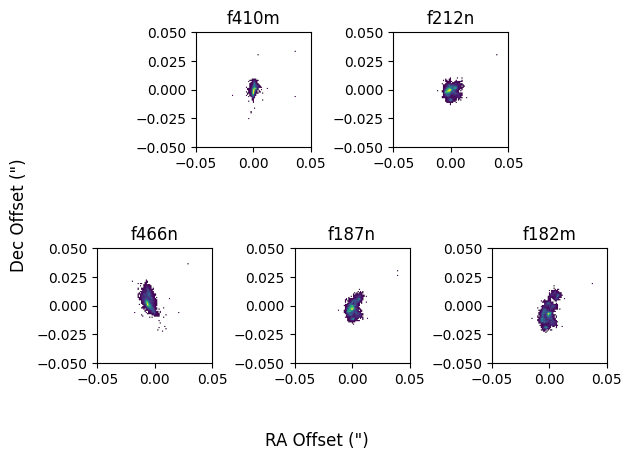

<Figure size 640x480 with 0 Axes>

In [32]:
#fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig1 = plt.figure(1)#, figsize=(15, 10))

basetable = cat_use.catalog
basecrds = basetable[f'skycoord_f405n']
radiffs = []
decdiffs = []

gridspec = sqgrid.get_grid(len(cat_use.filters)-1)
ii = 0
for i in range(6):
    filtername = cat_use.filters[i]
    if filtername == 'f405n':
        continue
    ax = fig1.add_subplot(gridspec[ii])#axes.flatten()[i]
    ii += 1

    thissel = ~basetable[f'flux_{filtername}'].mask & sel_cloudc
    crds = basetable[f'skycoord_{filtername}'][thissel]
    radiff = (crds.ra-basecrds.ra[thissel]).to(u.arcsec)
    decdiff = (crds.dec-basecrds.dec[thissel]).to(u.arcsec)
    rms_ra = np.sqrt(np.sum(radiff**2)/len(radiff))
    rms_dec = np.sqrt(np.sum(decdiff**2)/len(decdiff))
    rms = np.sqrt(rms_ra**2 + rms_dec**2)
    print(rms.to(u.mas))
    #print(rms_ra.to(u.mas), rms_dec.to(u.mas))

    sep = basetable[f'sep_{filtername}'][thissel].quantity.to(u.arcsec)

    hist = np.histogram2d(radiff.value, decdiff.value, bins=100, range=[[-0.05, 0.05], [-0.05, 0.05]])
    hist[0][hist[0]<1] = np.nan
    ax.imshow(hist[0].T, origin='lower', extent=[-0.05, 0.05, -0.05, 0.05], aspect='equal', cmap='viridis')#, vmin=0, vmax=np.percentile(hist[0], 99.5))
    #ax.scatter(radiff, decdiff, marker=',', s=1, alpha=0.01)
    ax.set_title(filtername)
    ax.set_xlim(-0.05, 0.05)
    ax.set_ylim(-0.05, 0.05)

fig1.supxlabel("RA Offset (\")")
fig1.supylabel("Dec Offset (\")")
fig1.tight_layout()

plt.tight_layout()

3.6925781437547918 mas
5.145812720712038 mas
8.87076517482103 mas
6.731905729910074 mas
11.422116674181739 mas


/scratch/local/29356267/ipykernel_1976316/4064364246.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


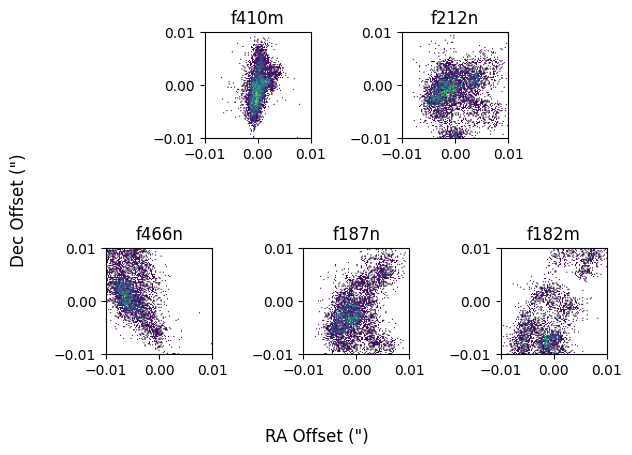

<Figure size 640x480 with 0 Axes>

In [33]:
#fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig1 = plt.figure(1)#, figsize=(15, 10))

basetable = cat_use.catalog
basecrds = basetable[f'skycoord_f405n']
radiffs = []
decdiffs = []

gridspec = sqgrid.get_grid(len(cat_use.filters)-1)
ii = 0
for i in range(6):
    filtername = cat_use.filters[i]
    if filtername == 'f405n':
        continue
    ax = fig1.add_subplot(gridspec[ii])#axes.flatten()[i]
    ii += 1

    thissel = ~basetable[f'flux_{filtername}'].mask & sel_cloudc
    crds = basetable[f'skycoord_{filtername}'][thissel]
    radiff = (crds.ra-basecrds.ra[thissel]).to(u.arcsec)
    decdiff = (crds.dec-basecrds.dec[thissel]).to(u.arcsec)
    rms_ra = np.sqrt(np.sum(radiff**2)/len(radiff))
    rms_dec = np.sqrt(np.sum(decdiff**2)/len(decdiff))
    rms = np.sqrt(rms_ra**2 + rms_dec**2)
    print(rms.to(u.mas))
    #print(rms_ra.to(u.mas), rms_dec.to(u.mas))

    sep = basetable[f'sep_{filtername}'][thissel].quantity.to(u.arcsec)

    hist = np.histogram2d(radiff.value, decdiff.value, bins=100, range=[[-0.01, 0.01], [-0.01, 0.01]])
    hist[0][hist[0]<1] = np.nan
    ax.imshow(hist[0].T, origin='lower', extent=[-0.01, 0.01, -0.01, 0.01], aspect='equal', cmap='viridis')#, vmin=0, vmax=np.percentile(hist[0], 99.5))
    #ax.scatter(radiff, decdiff, marker=',', s=1, alpha=0.01)
    ax.set_title(filtername)
    ax.set_xlim(-0.01, 0.01)
    ax.set_ylim(-0.01, 0.01)

fig1.supxlabel("RA Offset (\")")
fig1.supylabel("Dec Offset (\")")
fig1.tight_layout()

plt.tight_layout()